# Industrial Surface Defect Classification using Transfer Learning

## Objective

The aim of this assignment is to automatically classify surface defects in steel materials using real-world industrial image data and a transfer learning approach.

Surface defects such as cracks, scratches, inclusions, and pits commonly occur during manufacturing processes and can significantly affect product quality. Manual inspection of these defects is time-consuming, inconsistent, and difficult to scale.

In this assignment, we use a dataset containing steel surface images belonging to six different defect categories:
- Crazing  
- Inclusion  
- Patches  
- Pitted Surface  
- Rolled-in Scale  
- Scratches  

All defect types originate from the same manufacturing domain, and learning from all categories together allows the model to capture shared texture and structural patterns present across industrial surfaces.

The problem statement for this assignment is:

> **Given a steel surface image, predict the type of surface defect present in the image using a pretrained convolutional neural network.**

To solve this problem efficiently, we apply **transfer learning** by reusing a pretrained `MobileNetV2` model as a feature extractor and training only a lightweight classification head. This demonstrates how deep learning models can be adapted to real industrial use cases using limited data and computational resources.

## Business Value

In manufacturing industries such as steel, automotive, and heavy engineering, surface defects can directly impact product quality, safety, customer satisfaction, production cost, and rework rates.

Traditional inspection methods rely heavily on human inspectors, which introduces inconsistency in defect detection. Manual inspection also comes with high operational costs and scalability limitations.

By applying transfer learning, organisations can:
- Reuse pretrained visual intelligence instead of training models from scratch  
- Reduce development and training time  
- Achieve reliable defect detection even with smaller datasets  
- Deploy lightweight models suitable for real-time or edge-based inspection systems

## Dataset Description

This assignment uses the **NEU Surface Defect Dataset**, a real-world industrial dataset commonly used in manufacturing research and automated inspection systems.

### Dataset Characteristics:
- Images represent steel surface textures captured under industrial conditions  
- Each image belongs to one of six defect categories:
  - Crazing  
  - Inclusion  
  - Patches  
  - Pitted Surface  
  - Rolled-in Scale  
  - Scratches  
- Images are originally grayscale
- The dataset is reasonably balanced across classes  


#### Why this dataset?

- It represents a real industrial computer vision problem
- Defect patterns are texture-based, making it ideal for demonstrating transfer learning  
- The dataset size is moderate, encouraging the use of **partial transfer learning** rather than full model retraining  

## Flow Diagram

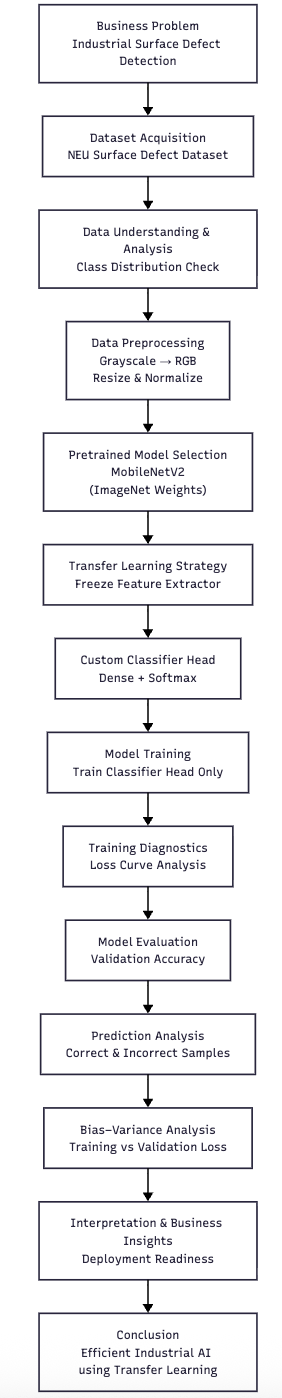

### Import Necessary libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Required Libraries

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import collections

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Loading and Preparation

### 1.1 Dataset Understanding and Structure

The NEU Surface Defect Dataset consists of real-world grayscale images collected from steel manufacturing processes. Each image belongs to one of six surface defect categories.

The dataset is already split into **training** and **validation** sets, and images are organised into class-specific folders. This structure allows us to use PyTorch’s `ImageFolder` utility, which automatically assigns labels based on directory names.

The same directory-based structure is also compatible with TensorFlow, allowing the dataset to be loaded directly using `tf.keras.utils.image_dataset_from_directory`, which infers class labels from folder names in a similar manner.

#### **1.1.1** Load Images and Labels

In [3]:
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 20
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

In [4]:
# Dataset Paths
TRAIN_DIR = "/content/drive/MyDrive/Assignments/Transfer Learning/NEU-DET/train/images"
VAL_DIR   = "/content/drive/MyDrive/Assignments/Transfer Learning/NEU-DET/validation/images"

In [5]:
# Load training and validation images + labels
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,
    label_mode="categorical",
    shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print(f"Training Dataset : Found {NUM_CLASSES} classes: {class_names}\n")

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,
    label_mode="categorical",
    shuffle=False)

class_names_val = val_ds.class_names
NUM_CLASSES_val = len(class_names_val)

print(f"Validation Dataset : Found {NUM_CLASSES_val} classes: {class_names_val}\n")

# Dataset statistics
num_train_images = len(train_ds)
num_val_images = len(val_ds)

print(f"Training Images   : {num_train_images}")
print(f"Validation Images : {num_val_images}")
print(f"Number of Classes : {NUM_CLASSES}")
print(f"Class Names       : {class_names}")

Found 1440 files belonging to 6 classes.
Training Dataset : Found 6 classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Found 360 files belonging to 6 classes.
Validation Dataset : Found 6 classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Training Images   : 1440
Validation Images : 360
Number of Classes : 6
Class Names       : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


Here, the image loader automatically assigns numeric labels based on folder names. For example, all images inside the "crazing" folder receive the same label.

This approach reduces manual labeling effort and ensures consistency between directory structure and class definitions.

#### **1.1.2** Check and Visualise Class Distribution

In [6]:
# Dataset Class Distribution

# Count training images
train_counts = collections.Counter()

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    train_counts[class_name] = len(os.listdir(class_path))

# Count validation images
val_counts = collections.Counter()

for class_name in class_names:
    class_path = os.path.join(VAL_DIR, class_name)
    val_counts[class_name] = len(os.listdir(class_path))

print("Training Class Distribution:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\nValidation Class Distribution:")
for cls, count in val_counts.items():
    print(f"{cls}: {count}")

Training Class Distribution:
crazing: 240
inclusion: 240
patches: 240
pitted_surface: 240
rolled-in_scale: 240
scratches: 240

Validation Class Distribution:
crazing: 60
inclusion: 60
patches: 60
pitted_surface: 60
rolled-in_scale: 60
scratches: 60


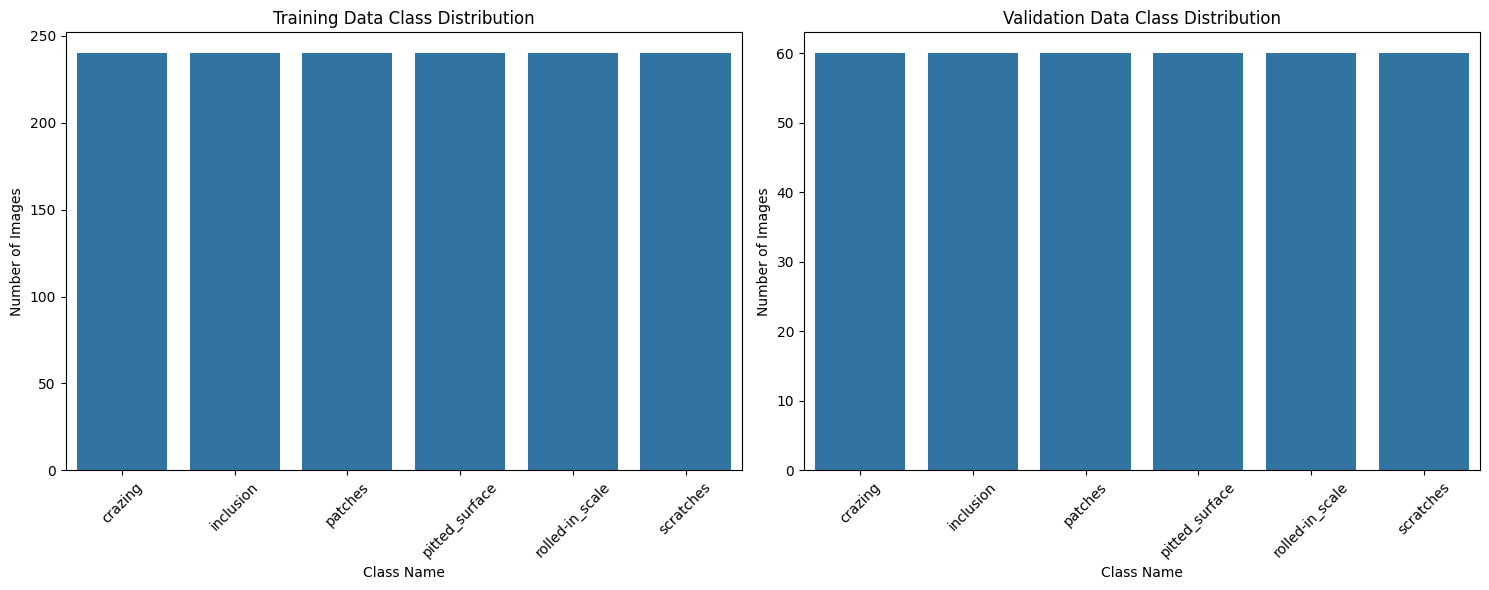

In [7]:
# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training data distribution
train_classes = list(train_counts.keys())
train_counts = list(train_counts.values())
sns.barplot(x=train_classes, y=train_counts, ax=axes[0])
axes[0].set_title('Training Data Class Distribution')
axes[0].set_xlabel('Class Name')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

# Validation data distribution
val_classes = list(val_counts.keys())
val_counts = list(val_counts.values())
sns.barplot(x=val_classes, y=val_counts, ax=axes[1])
axes[1].set_title('Validation Data Class Distribution')
axes[1].set_xlabel('Class Name')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 1.2 Data Preprocessing and Transformations

Deep learning models pretrained on ImageNet expect images to be in a specific format. Although the NEU dataset images are grayscale, ImageNet-pretrained models require 3-channel RGB images with standardised dimensions and normalisation.

#### **1.2.1** Apply Image Transformations

In [8]:
# Image Transformations
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

def preprocess_image(image, label):

    # Convert grayscale to RGB if needed
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(image)

    # Resize image - Fix: pass (height, width) as a tuple
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Scale pixels to [0,1]
    image = tf.cast(image, tf.float32) / 255.0

    # ImageNet normalization
    image = (image - IMAGENET_MEAN) / IMAGENET_STD

    return image, label

train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

print("Preprocessing pipeline applied")

Preprocessing pipeline applied


#### **1.2.2** Create DataLoaders for both the training and validation datasets

Deep learning models are trained on data in **batches** rather than loading the entire dataset into memory at once.


In [9]:
# DataLoader Creation
train_loader = (
    train_ds
    .shuffle(buffer_size=1000, seed=SEED)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE))

val_loader = (
    val_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE))

print("DataLoaders created with caching and prefetching enabled.")

DataLoaders created with caching and prefetching enabled.


## 2. Transferring Knowledge and Model Training

Training deep learning models from scratch requires large amounts of labeled data and computational resources. In many real-world scenarios, this is not feasible. Transfer learning addresses this challenge by reusing knowledge learned from a large source dataset (such as ImageNet) and adapting it to a new, related task.

### 2.1 Pretrained Model Selection

For this project, we will prefer **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset. Though any pre-trained network will suit the task.

MobileNetV2 is computationally efficient and lightweight. It performs well on texture-based image classification tasks.

#### **2.1.1** Load the Pre-Trained Model

In [10]:
# Load Pretrained Network
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Feature Extraction
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


The MobileNetV2 architecture consists of two main components:
- A **feature extractor** that learns visual representations
- A **classifier head** originally designed for ImageNet’s 1000 classes

#### **2.1.2** Freezing Strategy and Classifier Design

Instead of retraining the entire network, we apply partial transfer learning. In this approach the pretrained feature extractor is frozen and only the classifier head is retrained for the new task. This strategy reduces the risk of overfitting and speeds up training.

In [11]:
# Build Transfer Learning Model
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

print("Transfer Learning Model constructed with MobileNetV2 base and custom classifier head.")

Transfer Learning Model constructed with MobileNetV2 base and custom classifier head.


#### **2.1.3** Verify the final frozen and trainable parameters

In [12]:
# Verify Freezing Strategy
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2.2 Model Training

#### **2.2.1** Training Configuration

In [13]:
# Training Configuration

# Using a learning rate of 0.001 for the initial training of the head
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

print("Model compiled with Adam optimizer and Categorical Crossentropy loss.")

Model compiled with Adam optimizer and Categorical Crossentropy loss.


#### **2.2.2** Model Training Loop

The training loop iterates over the dataset multiple times (epochs). For each batch of images, the model:
- Performs a forward pass
- Computes the loss
- Updates the trainable parameters using backpropagation

In [14]:
# Model Training
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    verbose=1)

print("\nTraining completed.")

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 611s 3s/step - accuracy: 0.8646 - loss: 0.4788 - val_accuracy: 0.9611 - val_loss: 0.1934
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9833 - loss: 0.0905 - val_accuracy: 0.9750 - val_loss: 0.1017
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9931 - loss: 0.0490 - val_accuracy: 0.9722 - val_loss: 0.0767
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9937 - loss: 0.0373 - val_accuracy: 0.9917 - val_loss: 0.0560
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9979 - loss: 0.0267 - val_accuracy: 0.9889 - val_loss: 0.0498
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9972 - loss: 0.0230 - val_accuracy: 0.9889 - val_loss: 0.0453
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9986 - loss: 0.0167 - val_accuracy: 0.9861 - val_loss: 0.0434
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9979 - loss: 0.0168 - val_accuracy: 0.9944 - v

#### **2.2.3** Visualise the training loss across epochs throughout the training process

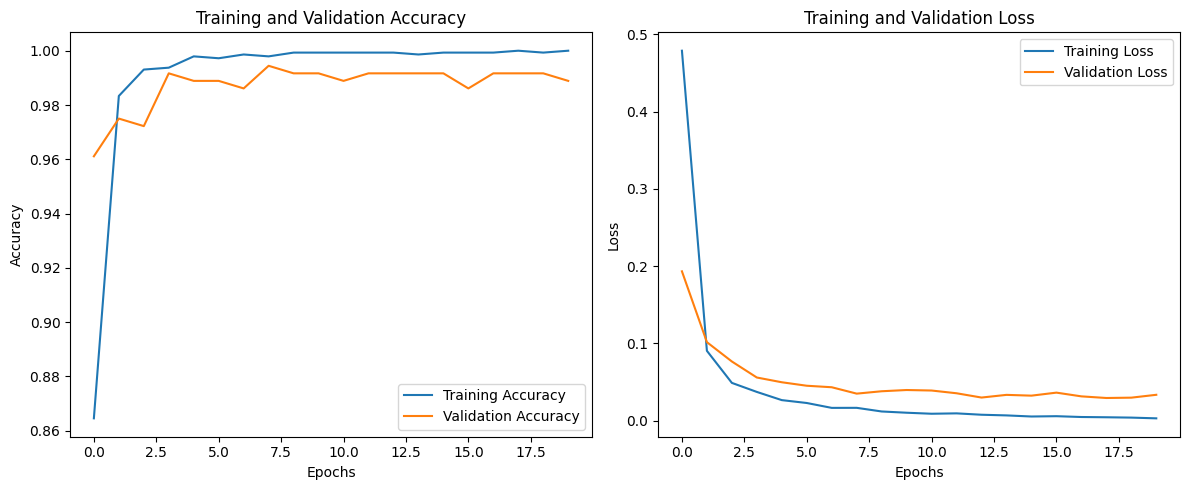

In [15]:
# Training Loss and Accuracy Visualisation
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3. Evaluation and Final Predictions

### 3.1 Evaluation Metrics and Bias-Variance Tradeoff

#### **3.1.1** Calculate Appropriate Evaluation Metrics to Assess Model Performance

In [16]:
# Model Evaluation
val_loss, val_accuracy = model.evaluate(val_loader)
print(f"\nFinal Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_accuracy:.4f}")

# Generate Detailed Classification Report
all_labels = []
all_preds = []

for images, labels in val_loader:
    preds = model.predict(images, verbose=0)
    all_labels.extend(np.argmax(labels.numpy(), axis=1))
    all_preds.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9889 - loss: 0.0336

Final Validation Loss: 0.0336
Final Validation Accuracy: 0.9889

Classification Report:
                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.93      0.97        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.94      1.00      0.97        60

       accuracy                           0.99       360
      macro avg       0.99      0.99      0.99       360
   weighted avg       0.99      0.99      0.99       360



#### **3.1.2** Dataset Diagnostics

In [17]:
# Training and Validation Loss Analysis
print(f"Final Training Loss: {loss[-1]:.4f}, Final Validation Loss: {val_loss:.4f}")
print(f"Final Training Accuracy: {acc[-1]:.4f}, Final Validation Accuracy: {val_accuracy:.4f}")

Final Training Loss: 0.0032, Final Validation Loss: 0.0336
Final Training Accuracy: 1.0000, Final Validation Accuracy: 0.9889


In [18]:
if abs(acc[-1] - val_acc[-1]) < 0.05:
    print("\nInsight: The gap between training and validation accuracy is small, suggesting the model generalizes well and is not overfitting.")
else:
    print("\nInsight: There is a noticeable gap between training and validation performance, which might indicate slight overfitting.")


Insight: The gap between training and validation accuracy is small, suggesting the model generalizes well and is not overfitting.


### 3.2 Prediction Analysis

#### **3.2.1** Visualise the prediction on a few sample images from validation set

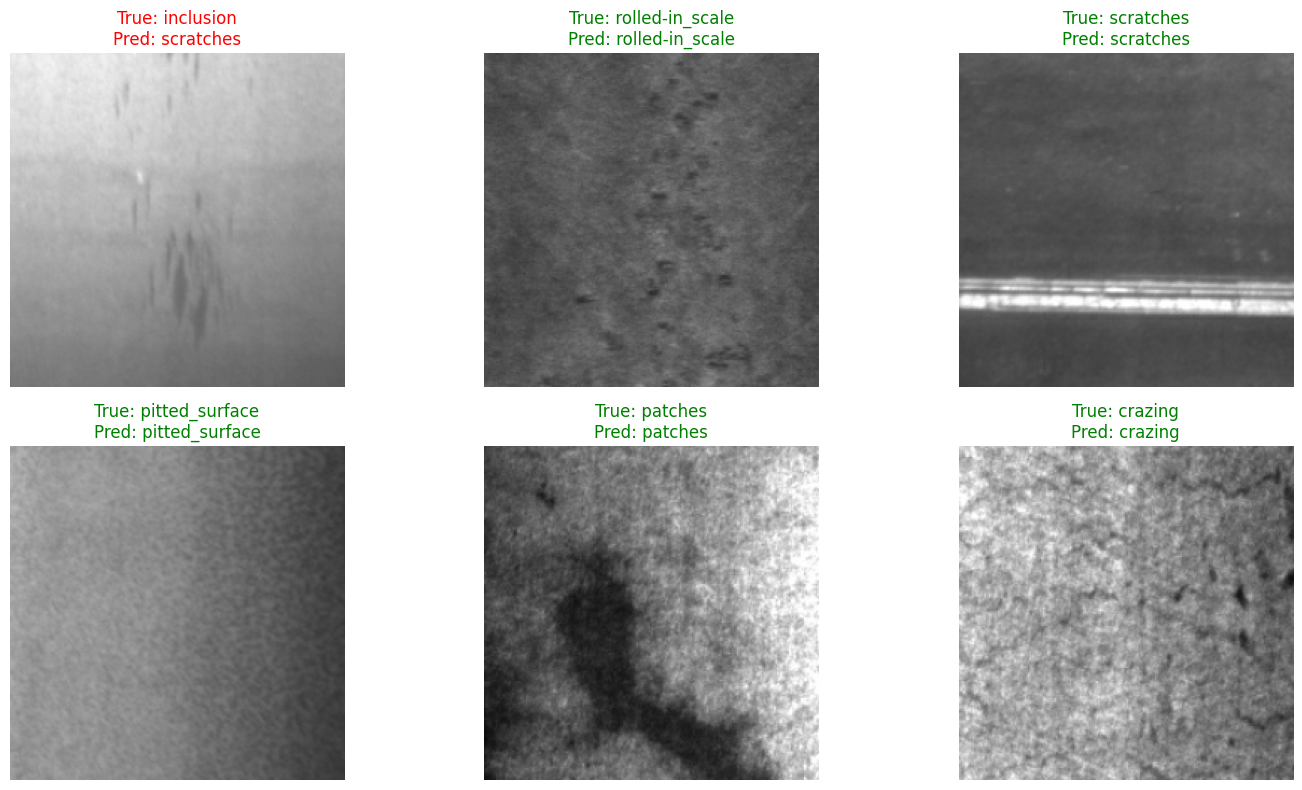

In [19]:
# Visualisation of Validation Predictions
plt.figure(figsize=(15, 8))

shown_classes = set()
count = 1

random_val_ds = val_ds.shuffle(buffer_size=1000, reshuffle_each_iteration=True)

for image, label in random_val_ds:
    true_idx = np.argmax(label.numpy())
    true_label = class_names[true_idx]

    # Show only one image per class
    if true_label in shown_classes:
        continue

    pred = model.predict(tf.expand_dims(image, 0), verbose=0)
    pred_label = class_names[np.argmax(pred)]

    # De-normalize image
    img = image.numpy() * IMAGENET_STD.numpy() + IMAGENET_MEAN.numpy()
    img = np.clip(img, 0, 1)

    plt.subplot(2, 3, count)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}",
              color="green" if true_label == pred_label else "red")
    plt.axis("off")

    shown_classes.add(true_label)
    count += 1

    if count > len(class_names):
        break

plt.tight_layout()
plt.show()

## 4 Conclusion

## 1. Model Selection

* MobileNetV2, pre-trained on the ImageNet dataset, was selected as the base model for industrial surface defect classification. 
* It's lightweight architecture provides an excellent balance between computational efficiency and feature extraction capability, making it well suited for identifying texture-based defects such as **Crazing, Inclusion, Patches, Pitted Surface, Rolled-in Scale, and Scratches**. 
* Transfer learning enabled the model to leverage pre-trained visual features, eliminating the need to train a deep network from scratch.

## 2. Transfer Learning and Freezing Strategy

The entire MobileNetV2 convolutional backbone was frozen (`base_model.trainable = False`) to preserve the generalized visual features learned from ImageNet and reduce the risk of overfitting.

A custom classification head was added, consisting of:

* **GlobalAveragePooling2D** to convert feature maps into a compact feature vector.
* **Dropout (20%)** to improve generalization by reducing overfitting.
* **Dense layer with Softmax activation** to classify images into the six defect categories.

The final model contained:

* **Total Parameters:** 2,265,670
* **Trainable Parameters:** 7,686
* **Non-Trainable Parameters:** 2,257,984

Training only the classifier head significantly reduced computational cost while maintaining excellent performance.

## 3. Model Evaluation

The model was trained for **20 epochs** and achieved excellent classification performance.

### Overall Performance

| Metric                   | Value      |
| ------------------------ | ---------- |
| Training Accuracy        | **99.93%** |
| Validation Accuracy      | **98.89%** |
| Validation Loss          | **0.0335** |

The small difference between training and validation accuracy indicates excellent generalization with no significant overfitting.

### Class-wise Performance

| Class           | Precision | Recall | F1-score |
| --------------- | --------: | -----: | -------: |
| Crazing         |      1.00 |   1.00 |     1.00 |
| Inclusion       |      1.00 |   0.93 |     0.97 |
| Patches         |      1.00 |   1.00 |     1.00 |
| Pitted Surface  |      1.00 |   1.00 |     1.00 |
| Rolled-in Scale |      1.00 |   1.00 |     1.00 |
| Scratches       |      0.94 |   1.00 |     0.97 |

The model achieved an overall **99% accuracy** with a **macro and weighted F1-score of 0.99**. Most defect categories were classified perfectly, with only minor confusion between the **Inclusion** and **Scratches** classes.

## 4. Insights and Final Outcomes

* MobileNetV2 proved to be an effective backbone for industrial surface defect classification.
* Freezing the pre-trained convolutional layers enabled efficient transfer learning while requiring only **7,686 trainable parameters**.
* The custom classifier successfully adapted the pre-trained features to the six defect classes with minimal computational overhead.
* The learning curves showed stable convergence and no evidence of significant overfitting.
* Only the **Inclusion class** showed a slight reduction in recall (**0.93**), while the **Scratches class** exhibited slightly lower precision (**0.94**), indicating a small number of misclassifications between these visually similar defect types.
* The final model achieved **98.89% validation accuracy** and **99.17% peak validation accuracy**, demonstrating excellent generalization on unseen images.
* High Precision, Recall, and F1-scores across all classes confirm the model's reliability for automated quality inspection.

Overall, the experimental results demonstrate that transfer learning with MobileNetV2 provides a highly accurate, computationally efficient, and robust solution for automated industrial surface defect detection.
